### svm_classifier

In this notebook, we attempt to predict nomination-worthy novels using an SVM

In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [2]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])
            ],
)

# svm cannot handle NaNs, so we fill with dummy values.
books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(99)
books_tt['month_of_publication'] = books_tt['month_of_publication'].fillna('Unknown')

We shall use **walk-forward nested time series cross-validation**.

In [8]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)

In [51]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

from sklearn.svm import LinearSVC
from sklearn import svm

# we compare a few different SVC-based models, to see how they perform.

model_dict = {
    'linearsvc_1': Pipeline([
    ('preprocess', feature_preprocessing),
    ('svc', LinearSVC(penalty='l2', class_weight={0: 1, 1: 5}))
]),

    'linearsvc_2': Pipeline([
    ('preprocess', feature_preprocessing),
    ('svc', LinearSVC(penalty='l2', class_weight='balanced'))
]),

    'linearsvc_3': Pipeline([
    ('preprocess', feature_preprocessing),
    ('svc', LinearSVC(penalty='l2', class_weight=None))
]),

    'svc': Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('svc', svm.SVC())
    ]
    ),

    'svc_weight_by_year': Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('svc', svm.SVC())
    ]
    ),

}

books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(99)

In [52]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.metrics import average_precision_score, ndcg_score
from sklearn.metrics import recall_score

# cv_data_allmodels = {}

for name, model in model_dict.items():

    print(name)

    cv_data = []

    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]

        book_train = book_train.copy()
        book_val = book_val.copy()

        year = book_val['release_year'].mode().values

        if name == 'svc_weight_by_year': # weight the older years less

            model.fit(book_train[features], book_train['target'],
                    svc__sample_weight=np.exp(-0.05*(max(book_train['release_year']) - book_train['release_year'])))

            ypred = model.predict(book_val[features])

        else:
            model.fit(book_train[features], book_train['target'])

            ypred = model.predict(book_val[features])

        book_val['predicted'] = ypred

        f1score = f1_score(book_val['target'], book_val['predicted'].values)
        recall = recall_score(book_val['target'], book_val['predicted'].values)
        precision = average_precision_score(book_val['target'], book_val['predicted'].values)

        cv_data.append({'fold': num, "val_year": year, 'f1_score': f1score, 'recall': recall, 'precision': precision})

    cv_data_allmodels[name] = cv_data

linearsvc_1
linearsvc_2
linearsvc_3
svc
svc_weight_by_year


In [53]:
for name, model in model_dict.items():
    cv_result = pd.DataFrame(cv_data_allmodels[name])
    print(name)
    print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
    print("STD of f1 score across folds: ", cv_result['f1_score'].std())

linearsvc_1
Mean f1 score across folds:  0.4457282469551946
STD of f1 score across folds:  0.07002234068967142
linearsvc_2
Mean f1 score across folds:  0.29575172781395553
STD of f1 score across folds:  0.06609401224058138
linearsvc_3
Mean f1 score across folds:  0.3338513934619745
STD of f1 score across folds:  0.10515028746114462
svc
Mean f1 score across folds:  0.31901750016297953
STD of f1 score across folds:  0.1311887511622169
svc_weight_by_year
Mean f1 score across folds:  0.3149954433556469
STD of f1 score across folds:  0.1270379107452655


linearsvc_1


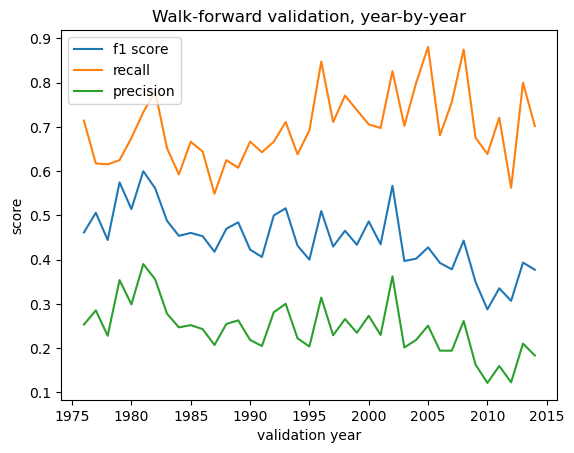

linearsvc_2


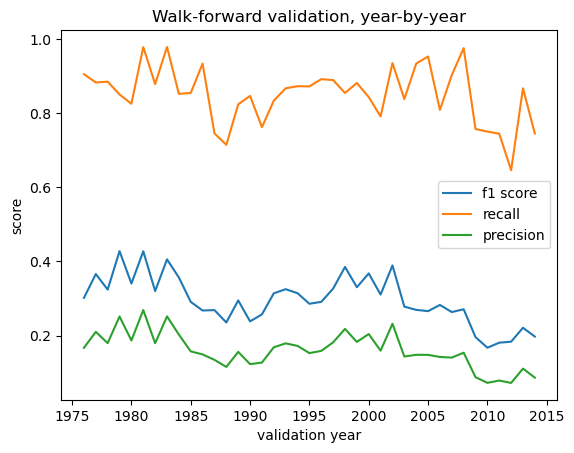

linearsvc_3


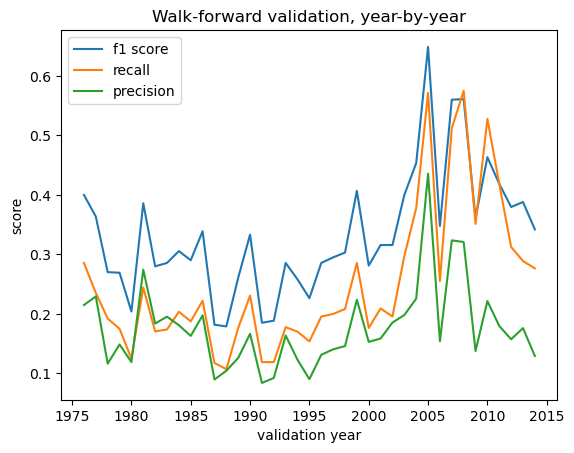

svc


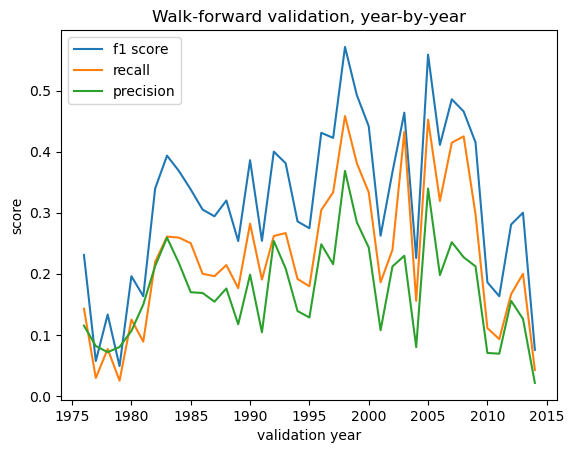

svc_weight_by_year


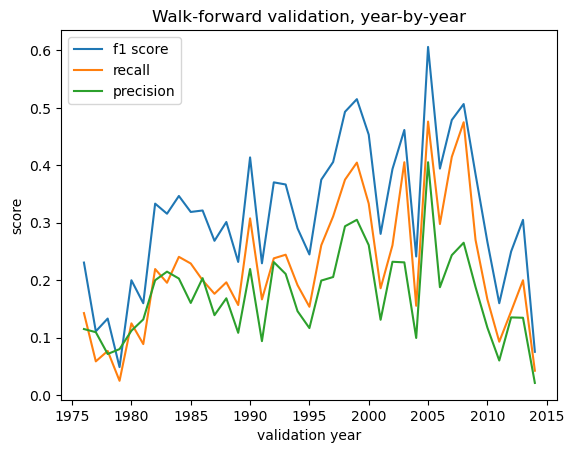

In [54]:
for name, model in model_dict.items():
    cv_result = pd.DataFrame(cv_data_allmodels[name])
    print(name)
    plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
    plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
    plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
    plt.xlabel("validation year")
    plt.ylabel("score")
    plt.title('Walk-forward validation, year-by-year')
    plt.legend()
    plt.show()

linearsvc_1


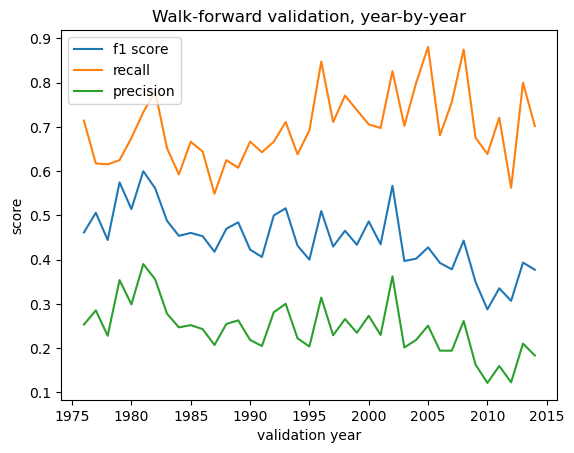

linearsvc_2


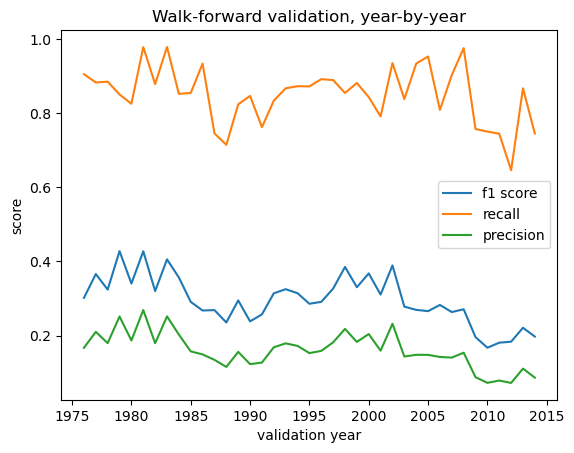

linearsvc_3


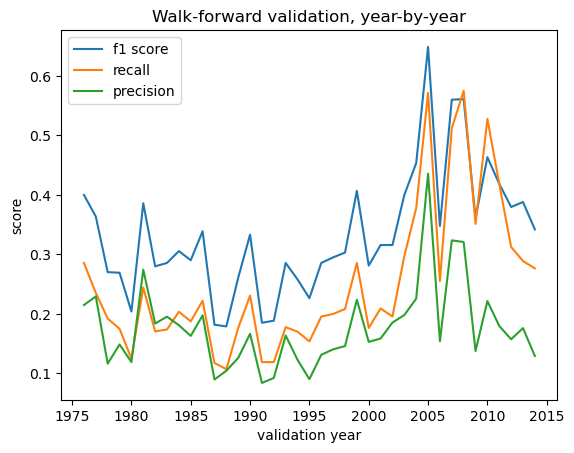

svc


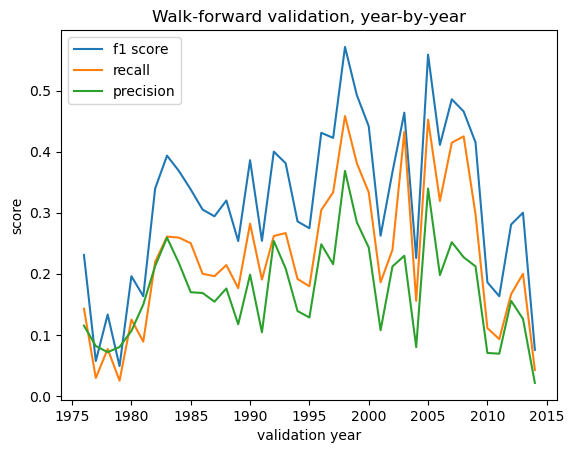

In [41]:
for name, model in model_dict.items():
    cv_result = pd.DataFrame(cv_data_allmodels[name])
    print(name)
    plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
    plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
    plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
    plt.xlabel("validation year")
    plt.ylabel("score")
    plt.title('Walk-forward validation, year-by-year')
    plt.legend()
    plt.show()

linearsvc_1


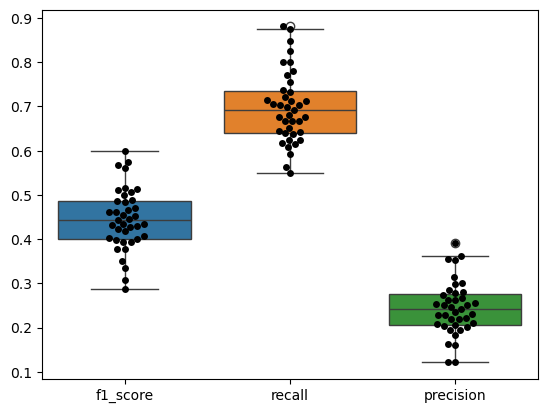

linearsvc_2


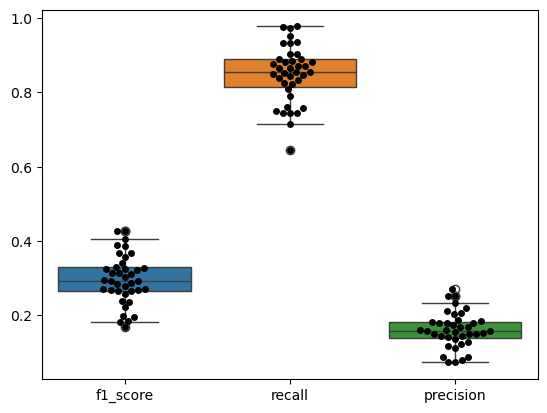

linearsvc_3


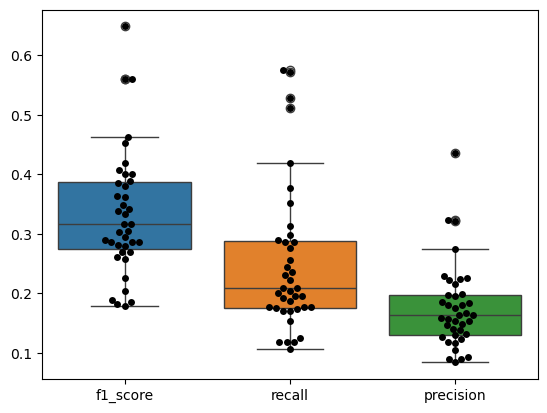

svc


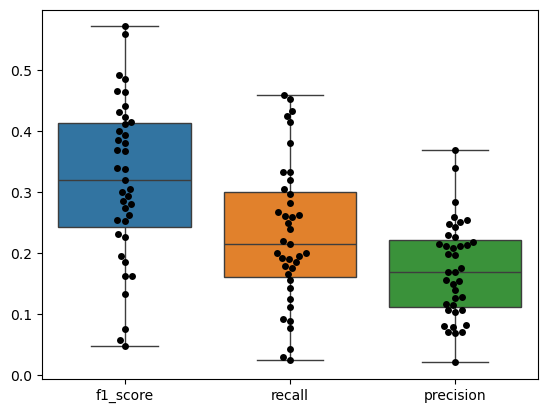

svc_weight_by_year


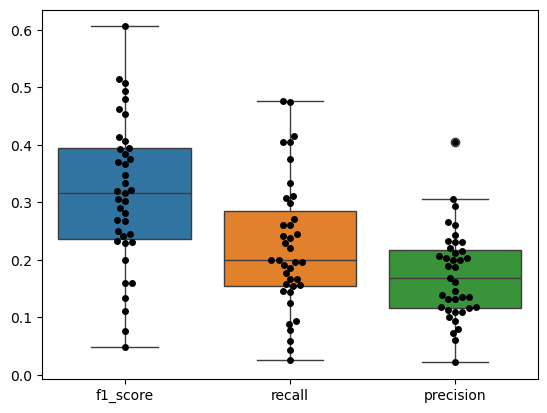

In [55]:
import seaborn as sns

for name, model in model_dict.items():
    cv_result = pd.DataFrame(cv_data_allmodels[name])
    print(name)

    ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

    sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')

    plt.show()


Let us look at the most important features.

In [21]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

coefs = model.named_steps['svc'].coef_[0] 

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficients': coefs,
    'Importance': np.abs(coefs)
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                          Feature  Coefficients  Importance
78             tag_similarity__cohort_similiarity     -3.862046    3.862046
79     nominee_similarity__past_winner_similarity      3.288776    3.288776
64             onehot__first_publisher_zebrabooks     -1.300715    1.300715
37              onehot__first_publisher_jovebooks     -1.228273    1.228273
17          onehot__first_publisher_bantamspectra      1.187012    1.187012
53        onehot__first_publisher_scholasticpress     -1.090459    1.090459
61                    onehot__first_publisher_tor      1.085008    1.085008
63      onehot__first_publisher_wizardsofthecoast     -1.072215    1.072215
45          onehot__first_publisher_pinnaclebooks     -1.019090    1.019090
25         onehot__first_publisher_delacortepress     -1.008627    1.008627
62                    onehot__first_publisher_tsr     -0.981456    0.981456
30               onehot__first_publisher_gollancz      0.977774    0.977774
43          

This model has a worse f1 score than the XGB ranker, across the board, and precision/recall which are very opposite. It may not be worth testing on the test set.